## Total Fuel Evaluation (Sum of Phase Models)

In this section, we evaluate total fuel consumption by combining the phase-level ML predictions.

Steps:
1. Load the November–December test flights from the feature table and obtain the ground-truth total fuel (`total_fuel_modeled`).  
   If a total column is not available, we compute it by summing the phase fuel columns.
2. Load phase prediction files (takeoff, climb, cruise, descent, landing) exported earlier as CSV.
3. Merge predictions by `flight_id` and set missing phase predictions to 0 (phase not present or not predicted).
4. Compute total predicted fuel as the sum of predicted phase fuels.
5. Merge predictions with ground truth and report overall error metrics (MAE and MAPE).
6. Print average predicted fuel per phase and inspect the largest absolute errors for debugging.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DB_PATH = "../opensky_updated.sqlite"
FEATURE_TABLE = "flight_phase_features_v2_physics"
YEAR = 2022

def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    month  = parts[2].astype(int)
    day    = parts[3].astype(int)
    hour   = parts[4].astype(int)
    minute = parts[5].astype(int)
    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return 100*np.mean(np.abs((y_true - y_pred)/np.clip(np.abs(y_true),1e-6,None)))

# --- load test truth ---
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month
test = df[df["month"].isin([11,12])].copy()

true_total_col = "total_fuel_modeled"
if true_total_col not in test.columns:
    phase_cols = ["takeoff_fuel","climb_fuel","cruise_fuel","descent_fuel","landing_fuel"]
    test["true_total"] = test[phase_cols].sum(axis=1)
    true_total_col = "true_total"

truth = test[["flight_id", true_total_col]].rename(columns={true_total_col:"true_total"})

csv_dir = ("csv_files")
for fname in (
    "pred_physics_takeoff.csv",
    "pred_physics_climb.csv",
    "pred_physics_cruise.csv",
    "pred_physics_descent.csv",
    "pred_physics_landing.csv",
):
    full = os.path.join(csv_dir, fname)
    if not os.path.exists(full):
        raise FileNotFoundError(f"prediction file not found: {full}")

p_takeoff = pd.read_csv(os.path.join(csv_dir, "pred_physics_takeoff.csv"))
p_climb   = pd.read_csv(os.path.join(csv_dir, "pred_physics_climb.csv"))
p_cruise  = pd.read_csv(os.path.join(csv_dir, "pred_physics_cruise.csv"))
p_descent = pd.read_csv(os.path.join(csv_dir, "pred_physics_descent.csv"))
p_landing = pd.read_csv(os.path.join(csv_dir, "pred_physics_landing.csv"))

pred_all = (p_takeoff
    .merge(p_climb, on="flight_id", how="outer")
    .merge(p_cruise, on="flight_id", how="outer")
    .merge(p_descent, on="flight_id", how="outer")
    .merge(p_landing, on="flight_id", how="outer")
)

for c in ["pred_physics_takeoff","pred_physics_climb","pred_physics_cruise","pred_physics_descent","pred_physics_landing"]:
    pred_all[c] = pred_all[c].fillna(0.0)

pred_all["pred_total"] = pred_all[["pred_physics_takeoff","pred_physics_climb","pred_physics_cruise","pred_physics_descent","pred_physics_landing"]].sum(axis=1)

# merge truth
pred_all = pred_all.merge(truth, on="flight_id", how="left")

mask = pred_all["true_total"].notna() & np.isfinite(pred_all["true_total"])
y_true = pred_all.loc[mask, "true_total"].to_numpy(float)
y_pred = pred_all.loc[mask, "pred_total"].to_numpy(float)

print("TOTAL RESULTS (sum of phase ML)")
print("N:", int(mask.sum()))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MAPE:", mape(y_true, y_pred))
print(f"MSE : {mean_squared_error(y_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"R²  : {r2_score(y_true, y_pred):.4f}")



print(pred_all[[
    "pred_physics_takeoff",
    "pred_physics_climb",
    "pred_physics_cruise",
    "pred_physics_descent",
    "pred_physics_landing"
]].mean())

pred_all["abs_err"] = abs(pred_all["true_total"] - pred_all["pred_total"])
pred_all.sort_values("abs_err", ascending=False).head(10)

TOTAL RESULTS (sum of phase ML)
N: 3505
MAE: 80.53959857039811
MAPE: 5.118736208922346
MSE : 16275.3077
RMSE: 127.5747
R²  : 0.9398
pred_physics_takeoff      47.704942
pred_physics_climb      1085.511257
pred_physics_cruise      259.919611
pred_physics_descent     326.904271
pred_physics_landing       8.297121
dtype: float64


,flight_id,pred_physics_takeoff,pred_physics_climb,pred_physics_cruise,pred_physics_descent,pred_physics_landing,pred_total,true_total,abs_err
2575,47a1ef-NOZ141-12-23-08-04,46.403923,1424.4509,224.389729,325.49110,8.300641,2029.036293,871.30,1157.736293
1275,4792a6-NOZ140-12-01-06-59,48.210940,1154.4507,321.061671,336.17975,7.698275,1867.601336,788.40,1079.201336
2073,479ee7-NOZ50A-12-29-17-57,0.000000,1692.8600,1035.697751,319.17148,12.539081,3060.268312,4099.73,1039.461688
3010,47a3b0-NOZ144-11-01-15-43,43.050648,1318.0537,264.539797,365.91254,8.432636,1999.989321,990.79,1009.199321
2576,47a1ef-NOZ142-11-20-13-39,57.443054,1342.4830,192.349077,302.55530,8.324141,1903.154573,919.33,983.824573
906,4791ac-NOZ140-11-10-07-06,46.951880,1279.9271,208.361273,373.88895,8.090091,1917.219294,971.54,945.679294
2738,47a22c-NOZ141-11-17-08-01,46.421220,1284.5812,284.723247,308.27032,8.202731,1932.198718,991.16,941.038718
3007,47a3b0-NOZ141-11-04-08-13,51.684258,1394.2592,125.783195,317.09488,8.516431,1897.337964,976.43,920.907964
148,478742-NOZ145-11-21-16-51,57.321075,1305.1279,267.457659,316.07953,7.961719,1953.947883,1043.98,909.967883
2649,47a218-NOZ145-12-09-17-23,50.608364,1296.6913,253.787123,313.26706,7.636068,1921.989916,1067.18,854.809916


# Plot estimated vs actual total fuel

Removed 5 outliers (0.1%)


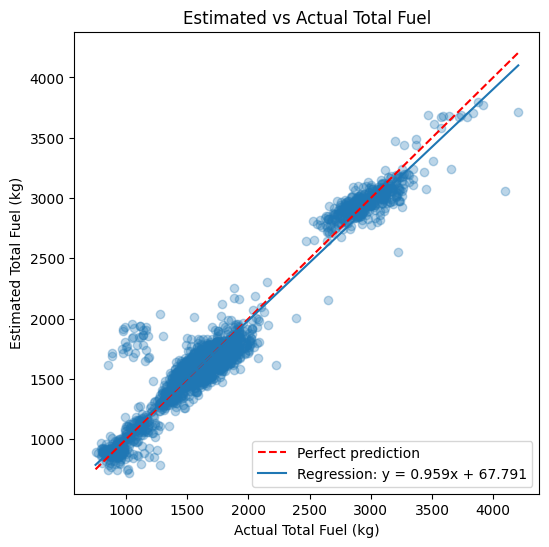

In [2]:
# Remove outliers (both over- and under-predictions)
before = len(pred_all)
pred_all = pred_all[
    (pred_all["pred_total"] <= 2 * pred_all["true_total"]) &
    (pred_all["pred_total"] >= 0.5 * pred_all["true_total"])
]
after = len(pred_all)

print(f"Removed {before - after} outliers ({(before - after)/before:.1%})")

plt.figure(figsize=(6,6))

plt.scatter(
    pred_all["true_total"],
    pred_all["pred_total"],
    alpha=0.3
)

# Perfect prediction line
min_val = pred_all["true_total"].min()
max_val = pred_all["true_total"].max()

plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

# Regression line (actual trend)
m, b = np.polyfit(pred_all["true_total"], pred_all["pred_total"], 1)
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, m*x_line + b, label=f"Regression: y = {m:.3f}x + {b:.3f}")

plt.xlabel("Actual Total Fuel (kg)")
plt.ylabel("Estimated Total Fuel (kg)")
plt.title("Estimated vs Actual Total Fuel")
plt.legend()
plt.legend(loc="lower right")
plt.show()

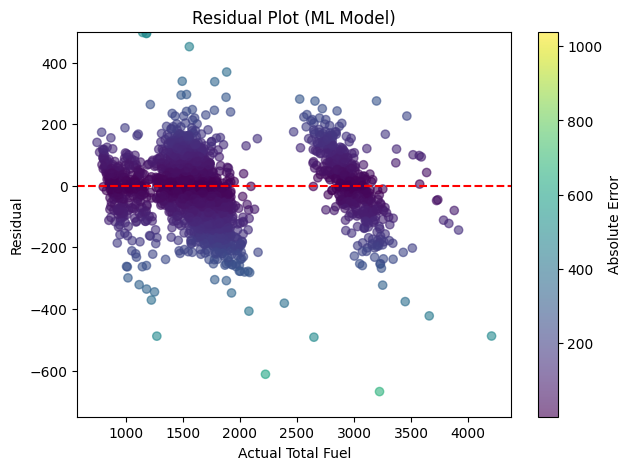

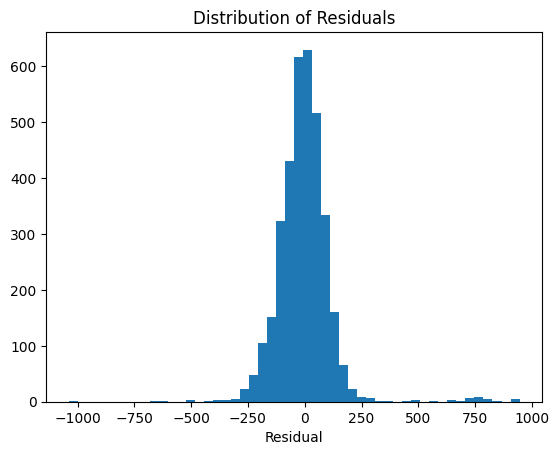

In [3]:
# compute residual (prediction - truth) if not already computed
if "residual" not in pred_all.columns:
    pred_all["residual"] = pred_all["pred_total"] - pred_all["true_total"]

plt.figure(figsize=(7,5))

plt.ylim(-750, 500)

plt.scatter(
    pred_all["true_total"],
    pred_all["residual"],
    c=pred_all["abs_err"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Absolute Error")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Actual Total Fuel")
plt.ylabel("Residual")
plt.title("Residual Plot (ML Model)")

plt.show()

plt.hist(pred_all["residual"], bins=50)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.show()

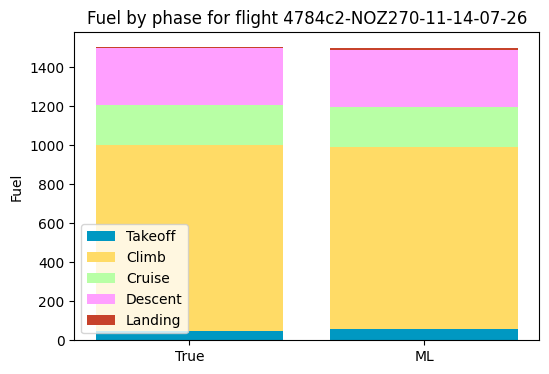

In [4]:
phases_true = [
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]

phases_pred = [
    "pred_physics_takeoff",
    "pred_physics_climb",
    "pred_physics_cruise",
    "pred_physics_descent",
    "pred_physics_landing"
]

colors = {
    "takeoff_fuel": "#0098c2",
    "climb_fuel": "#ffdb66",
    "cruise_fuel": "#b8ffa5",
    "descent_fuel": "#ff9fff",
    "landing_fuel": "#c7422b"
}


phase_truth = test[[
    "flight_id",
    "takeoff_fuel",
    "climb_fuel",
    "cruise_fuel",
    "descent_fuel",
    "landing_fuel"
]].drop_duplicates("flight_id")

pred_all = pred_all.merge(phase_truth, on="flight_id", how="left")

row = pred_all.iloc[3]

fig, ax = plt.subplots(figsize=(6,4))

bottom_true = 0
bottom_pred = 0

for true_col, pred_col in zip(phases_true, phases_pred):

    ax.bar(
        "True",
        row[true_col],
        bottom=bottom_true,
        color=colors[true_col],
        label=true_col.replace("_fuel","").capitalize()
    )

    ax.bar(
        "ML",
        row[pred_col],
        bottom=bottom_pred,
        color=colors[true_col]
    )

    bottom_true += row[true_col]
    bottom_pred += row[pred_col]

ax.set_ylabel("Fuel")
ax.set_title(f"Fuel by phase for flight {row['flight_id']}")

ax.legend()

plt.show()

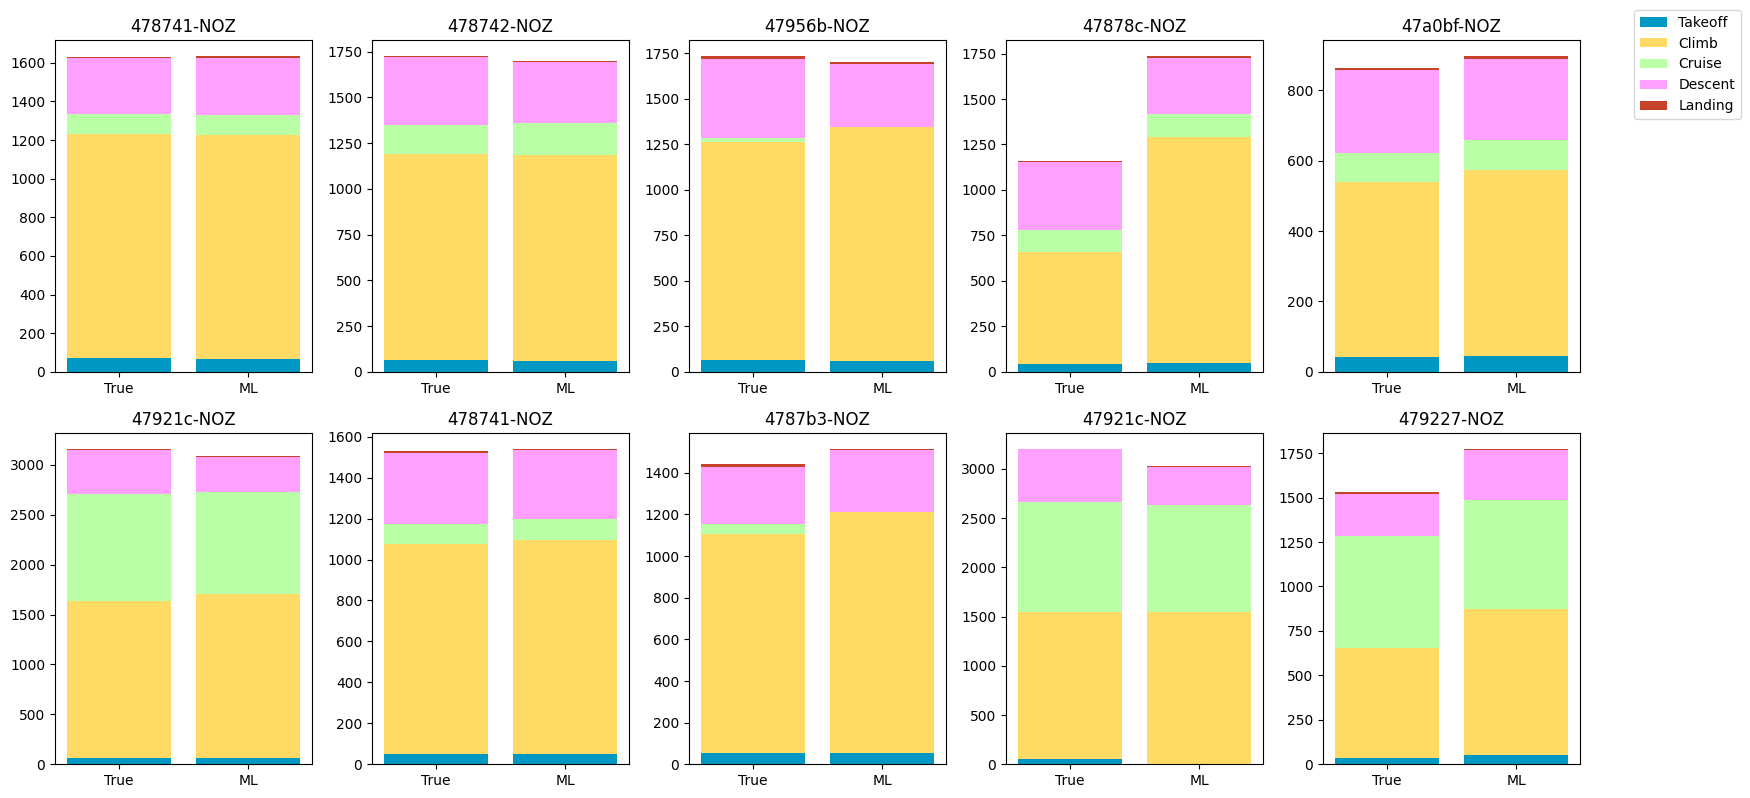

In [5]:
n = 10
sample = pred_all.sample(n, random_state=2)

cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16,4*rows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):

    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col in zip(phases_true, phases_pred):

        label = true_col.replace("_fuel","").capitalize()

        ax.bar(
            "True",
            row[true_col],
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "ML",
            row[pred_col],
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_title(row["flight_id"][:10])
    ax.set_xticks([0,1])
    ax.set_xticklabels(["True","ML"])

# fjern tomme plots
for ax in axes[n:]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

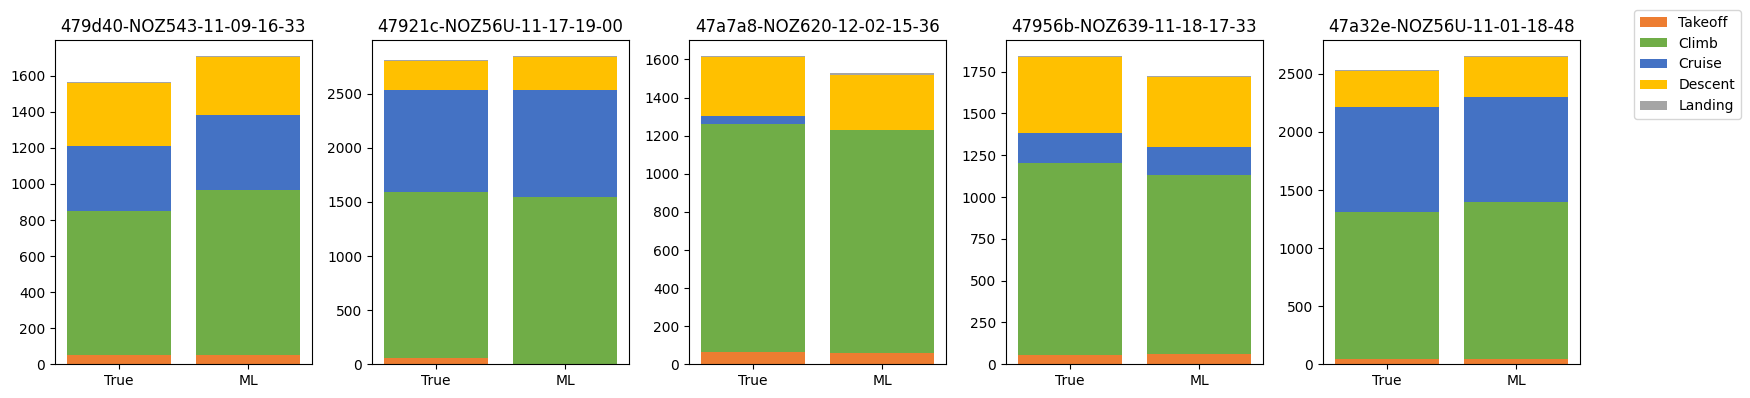

In [6]:
n = 5
sample = pred_all.sample(n)

cols = 5
rows = 1

fig, axes = plt.subplots(rows, cols, figsize=(16,4))
axes = axes.flatten()

colors = {
    "takeoff_fuel": "#c7422b",
    "climb_fuel": "#ff9fff",
    "cruise_fuel": "#ffdb66",
    "descent_fuel": "#b8ffa5",
    "landing_fuel": "#0098c2"
}
colors = {
    "takeoff_fuel": "#ED7D31",     # orange
    "climb_fuel": "#70AD47",    # green
    "cruise_fuel": "#4472C4",   # blue
    "descent_fuel": "#FFC000",   # yellow
    "landing_fuel": "#A5A5A5"    # grey
}

for ax, (_, row) in zip(axes, sample.iterrows()):

    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col in zip(phases_true, phases_pred):

        label = true_col.replace("_fuel","").capitalize()

        ax.bar(
            "True",
            row[true_col],
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "ML",
            row[pred_col],
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += row[true_col]
        bottom_pred += row[pred_col]

    ax.set_title(row["flight_id"])   # full id
    ax.set_xticks([0,1])
    ax.set_xticklabels(["True","ML"])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

In [8]:


# =====================================================
# ROUTE-LEVEL AVERAGE STACKED BARS
# =====================================================

truth_detail = truth_detail.rename(columns={
    "takeoff_fuel": "true_takeoff_fuel",
    "climb_fuel": "true_climb_fuel",
    "cruise_fuel": "true_cruise_fuel",
    "descent_fuel": "true_descent_fuel",
    "landing_fuel": "true_landing_fuel"
})

phases_true = [
    "true_takeoff_fuel",
    "true_climb_fuel",
    "true_cruise_fuel",
    "true_descent_fuel",
    "true_landing_fuel"
]

phases_pred = [
    "pred_physics_takeoff",
    "pred_physics_climb",
    "pred_physics_cruise",
    "pred_physics_descent",
    "pred_physics_landing"
]

phase_labels = ["Takeoff", "Climb", "Cruise", "Descent", "Landing"]

colors = {
    "takeoff_fuel": "#ED7D31",
    "climb_fuel": "#70AD47",
    "cruise_fuel": "#4472C4",
    "descent_fuel": "#FFC000",
    "landing_fuel": "#A5A5A5"
}

selected_routes = [
    "ENBO → ENGM",
    "ENBR → ENEV",
    "ENBR → ENGM",
    "ENBR → ENVA",
    "ENBR → ENZV",
    "ENCN → ENGM",
    "ENEV → ENBR",
    "ENEV → ENGM",
    "ENGM → ENBO",
    "ENGM → ENBR",
    "ENGM → ENCN",
    "ENGM → ENEV",
    "ENGM → ENHD",
    "ENGM → ENVA",
    "ENGM → ENZV",
    "ENHD → ENGM",
    "ENVA → ENBR",
    "ENVA → ENGM",
    "ENZV → ENBR",
    "ENZV → ENGM"
]

# Route columns in this dataset
dep_col = "estdepartureairport"
arr_col = "estarrivalairport"

# Keep one row per flight with route + true phase info
truth_detail = test[
    ["flight_id", dep_col, arr_col] + phases_true
].drop_duplicates(subset="flight_id").copy()

truth_detail = truth_detail.dropna(subset=[dep_col, arr_col])

truth_detail["route"] = (
    truth_detail[dep_col].astype(str) + " → " + truth_detail[arr_col].astype(str)
)

# Merge route + true phase info into prediction dataframe
plot_df = pred_all.merge(
    truth_detail[["flight_id", "route"] + phases_true],
    on="flight_id",
    how="inner"
)

# Filter to selected routes
plot_df = plot_df[plot_df["route"].isin(selected_routes)].copy()

if plot_df.empty:
    raise ValueError("No rows left after merging and filtering selected routes.")

# Average per route
avg_true = plot_df.groupby("route")[phases_true].mean()
avg_pred = plot_df.groupby("route")[phases_pred].mean()

# Preserve route order
avg_true = avg_true.reindex(selected_routes)
avg_pred = avg_pred.reindex(selected_routes)

# Drop routes with no data
valid_routes = avg_true.dropna(how="all").index
avg_true = avg_true.loc[valid_routes]
avg_pred = avg_pred.loc[valid_routes]

# Summary
summary_df = pd.DataFrame(index=avg_true.index)
summary_df["true_total"] = avg_true.sum(axis=1)
summary_df["physics_total"] = avg_pred.sum(axis=1)
summary_df["n_flights"] = plot_df.groupby("route").size().reindex(avg_true.index)

print("\nAverage total fuel burn per route:")
print(summary_df.round(2))

# -----------------------------
# Plot stacked bar charts
# -----------------------------
n_routes = len(avg_true)
ncols = 5
nrows = int(np.ceil(n_routes / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 5 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for ax, route in zip(axes, avg_true.index):
    bottom_true = 0
    bottom_pred = 0

    for true_col, pred_col, label in zip(phases_true, phases_pred, phase_labels):
        true_val = avg_true.loc[route, true_col]
        pred_val = avg_pred.loc[route, pred_col]

        ax.bar(
            "True",
            true_val,
            bottom=bottom_true,
            color=colors[true_col],
            label=label
        )

        ax.bar(
            "Physics",
            pred_val,
            bottom=bottom_pred,
            color=colors[true_col]
        )

        bottom_true += true_val
        bottom_pred += pred_val

    route_max = max(bottom_true, bottom_pred)
    ax.set_ylim(0, route_max * 1.1)

    n_flights = int(summary_df.loc[route, "n_flights"])
    ax.set_title(f"{route}\n(n={n_flights})", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["True", "Physics"], fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

    ax.text(
        0, bottom_true + route_max * 0.02, f"{bottom_true:.0f}",
        ha="center", va="bottom", fontsize=8
    )
    ax.text(
        1, bottom_pred + route_max * 0.02, f"{bottom_pred:.0f}",
        ha="center", va="bottom", fontsize=8
    )

# Hide unused axes
for ax in axes[len(avg_true):]:
    ax.axis("off")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(
    unique.values(),
    unique.keys(),
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Flight phase"
)

fig.suptitle("Average Fuel Burn by Route and Flight Phase (Physics)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()

KeyError: "Columns not found: 'descent_fuel', 'climb_fuel', 'takeoff_fuel', 'landing_fuel', 'cruise_fuel'"